In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path().resolve().parent
CACHE_DIR = PROJECT_ROOT / "data" / "raw"

CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["KAGGLEHUB_CACHE"] = str(CACHE_DIR)

import kagglehub

path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
print(path)

e:\digitalfutures\VSCode\repo\capstone-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


E:\digitalfutures\VSCode\repo\capstone-project\data\raw\datasets\clmentbisaillon\fake-and-real-news-dataset\versions\1


In [2]:
from pathlib import Path
import pandas as pd
import os

path = Path(path)

df_fake = pd.read_csv(path / "Fake.csv")
df_true = pd.read_csv(path / "True.csv")

In [3]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
df_fake = df_fake.assign(label="0")
df_true = df_true.assign(label="1")

In [5]:
df_fake = df_fake.drop(columns=["subject", "date"])
df_true = df_true.drop(columns=["subject", "date"])

In [6]:
df_news = pd.concat([df_fake, df_true], ignore_index=True)
df_news

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0
...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,1
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",1
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,1
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,1


In [7]:
df_news.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [8]:
df_news.duplicated().sum()

np.int64(5793)

In [9]:
df_news.drop_duplicates(inplace=True)

In [10]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np

nltk.download('wordnet', "/kaggle/working/nltk_data/")
nltk.download('omw-1.4', "/kaggle/working/nltk_data/")
nltk.download('punkt_tab', "/kaggle/working/nltk_data/")
nltk.download('stopwords', "/kaggle/working/nltk_data/")

[nltk_data] Downloading package wordnet to
[nltk_data]     /kaggle/working/nltk_data/...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /kaggle/working/nltk_data/...
[nltk_data]   Unzipping corpora\omw-1.4.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /kaggle/working/nltk_data/...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /kaggle/working/nltk_data/...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
import zipfile
import os

zip_paths = [
    "/kaggle/working/nltk_data/corpora/wordnet.zip",
    "/kaggle/working/nltk_data/corpora/omw-1.4.zip",
    "/kaggle/working/nltk_data/tokenizers/punkt_tab.zip",
    "/kaggle/working/nltk_data/corpora/stopwords.zip"
]

extract_dir = "/kaggle/working/nltk_data/corpora"

os.makedirs(extract_dir, exist_ok=True)

for z in zip_paths:
    with zipfile.ZipFile(z, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
nltk.data.path.append("/kaggle/working/nltk_data/")

In [12]:
def process_text(text):
    text = re.sub(
        r"\s+", " ", text, flags=re.I
    )  # Remove extra white space from text

    text = re.sub(
        r"\W", " ", str(text)
    )  # Remove all the special characters from text

    text = re.sub(
        r"\s+[a-zA-Z]\s+", " ", text
    )  # Remove all single characters from text

    text = re.sub(
        r"[^a-zA-Z\s]", "", text
    )  # Remove any character that isn't alphabetical

    text = text.lower()

    words = word_tokenize(text)

    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    stop_words = set(stopwords.words("english"))
    Words = [word for word in words if word not in stop_words]

    Words = [word for word in Words if len(word) > 3]

    indices = np.unique(Words, return_index=True)[1]
    cleaned_text = np.array(Words)[np.sort(indices)].tolist()

    return cleaned_text

In [13]:
x = df_news.drop("label", axis=1)
y = df_news.label

In [14]:
texts = list(x["text"])

In [15]:
cleaned_text = [process_text(text) for text in texts]

In [16]:
print(cleaned_text[:5])

[['donald', 'trump', 'wish', 'american', 'happy', 'year', 'leave', 'instead', 'give', 'shout', 'enemy', 'hater', 'dishonest', 'fake', 'news', 'medium', 'former', 'reality', 'show', 'star', 'country', 'rapidly', 'grows', 'stronger', 'smarter', 'want', 'friend', 'supporter', 'even', 'healthy', 'president', 'angry', 'pant', 'tweeted', 'great', 'america', 'realdonaldtrump', 'december', 'tweet', 'went', 'welll', 'expect', 'kind', 'sends', 'greeting', 'like', 'despicable', 'petty', 'infantile', 'gibberish', 'lack', 'decency', 'allow', 'rise', 'gutter', 'long', 'enough', 'citizen', 'bishop', 'talbert', 'swan', 'talbertswan', 'calvin', 'calvinstowell', 'impeachment', 'would', 'make', 'also', 'accept', 'regaining', 'control', 'congress', 'miranda', 'yaver', 'mirandayaver', 'hear', 'talk', 'include', 'many', 'people', 'hate', 'wonder', 'alan', 'sandoval', 'alansandoval', 'word', 'marlene', 'koren', 'pollitt', 'korencarpenter', 'including', 'fought', 'lost', 'badly', 'know', 'love', 'nothing', 'd

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    cleaned_text, y, test_size=0.2, random_state=42
)

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

tokenizer = Tokenizer()
tokenizer.fit_on_texts(x_train)
word_idx = tokenizer.word_index
v = len(word_idx)
print("the size of vocab =", v)
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
x_train = tokenizer.texts_to_sequences(x_train)
x_test = tokenizer.texts_to_sequences(x_test)

the size of vocab = 91457


In [19]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 200
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

In [20]:
y.value_counts()

label
1    21197
0    17908
Name: count, dtype: int64

In [21]:
from keras.models import Sequential
from keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Input,
    GlobalMaxPooling1D,
    Dropout,
)
from tensorflow.keras.models import Model
from keras import optimizers
import numpy as np
from tensorflow.keras.optimizers import Adam

In [ ]:
input = Input(shape=(maxlen,))
learning_rate = 0.0001
x = Embedding(v + 1, 100)(input)
x = Dropout(0.5)(x)
x = LSTM(150, return_sequences=True)(x)
x = Dropout(0.5)(x)
x = GlobalMaxPooling1D()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(2, activation="softmax")(x)

model = Model(input, x)

optimizer = Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
)

In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [24]:
import tensorflow as tf

y_train_one_hot = tf.keras.utils.to_categorical(y_train_encoded)
y_test_one_hot = tf.keras.utils.to_categorical(y_test_encoded)

In [25]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
)

history = model.fit(
    x_train,
    y_train_one_hot,
    epochs=3,
    validation_data=(x_test, y_test_one_hot),
    callbacks=[checkpoint],
)

Epoch 1/3
978/978 ━━━━━━━━━━━━━━━━━━━━ 113s 114ms/step - accuracy: 0.8366 - loss: 0.3113 - val_accuracy: 0.9825 - val_loss: 0.0853
Epoch 2/3
978/978 ━━━━━━━━━━━━━━━━━━━━ 124s 127ms/step - accuracy: 0.9866 - loss: 0.0442 - val_accuracy: 0.9862 - val_loss: 0.0498
Epoch 3/3
978/978 ━━━━━━━━━━━━━━━━━━━━ 124s 127ms/step - accuracy: 0.9935 - loss: 0.0255 - val_accuracy: 0.9868 - val_loss: 0.0459


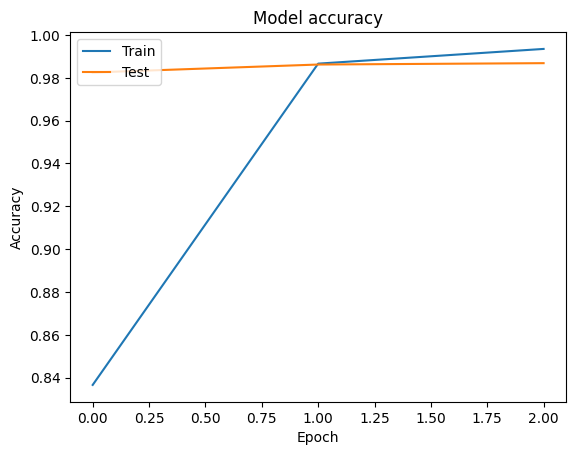

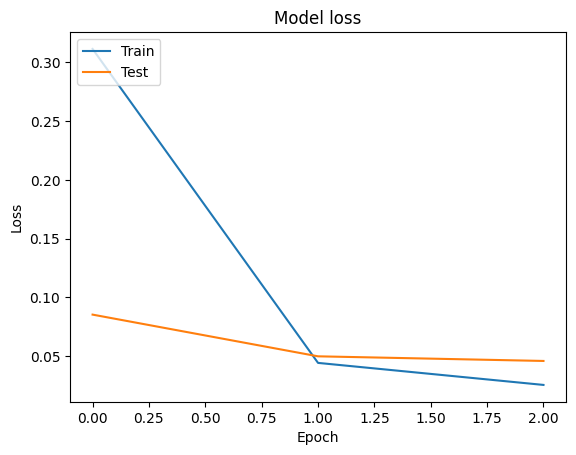

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Test"], loc="upper left")
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"], loc="upper left")
plt.show()

#### Parameters testsize=.1 maxlen=150 epochs=5
Epoch 1/5 1100/1100 ━━━━━━━━━━━━━━━━━━━━ 114s 102ms/step - accuracy: 0.8381 - loss: 0.3192 - val_accuracy: 0.9724 - val_loss: 0.1697<br>
Epoch 2/5 1100/1100 ━━━━━━━━━━━━━━━━━━━━ 109s 99ms/step - accuracy: 0.9779 - loss: 0.0702 - val_accuracy: 0.9790 - val_loss: 0.1290<br>
Epoch 3/5 1100/1100 ━━━━━━━━━━━━━━━━━━━━ 106s 96ms/step - accuracy: 0.9882 - loss: 0.0421 - val_accuracy: 0.9808 - val_loss: 0.1111<br>
Epoch 4/5 1100/1100 ━━━━━━━━━━━━━━━━━━━━ 107s 97ms/step - accuracy: 0.9933 - loss: 0.0253 - val_accuracy: 0.9813 - val_loss: 0.0681<br>
Epoch 5/5 1100/1100 ━━━━━━━━━━━━━━━━━━━━ 109s 99ms/step - accuracy: 0.9962 - loss: 0.0149 - val_accuracy: 0.9795 - val_loss: 0.0698<br>

#### Parameters testsize=.1 maxlen=200 epochs=5
Epoch 1/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 104s 94ms/step - accuracy: 0.9973 - loss: 0.0110 - val_accuracy: 0.9793 - val_loss: 0.0594<br>
Epoch 2/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 106s 96ms/step - accuracy: 0.9981 - loss: 0.0074 - val_accuracy: 0.9798 - val_loss: 0.0654<br>
Epoch 3/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 106s 96ms/step - accuracy: 0.9986 - loss: 0.0058 - val_accuracy: 0.9798 - val_loss: 0.0656<br>
Epoch 4/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 112s 102ms/step - accuracy: 0.9989 - loss: 0.0039 - val_accuracy: 0.9793 - val_loss: 0.0650<br>
Epoch 5/5
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 114s 104ms/step - accuracy: 0.9990 - loss: 0.0033 - val_accuracy: 0.9778 - val_loss: 0.0677<br>

#### Parameters testsize=.2 maxlen=200 epochs=3
Epoch 1/3
978/978 ━━━━━━━━━━━━━━━━━━━━ 113s 114ms/step - accuracy: 0.8366 - loss: 0.3113 - val_accuracy: 0.9825 - val_loss: 0.0853<br>
Epoch 2/3
978/978 ━━━━━━━━━━━━━━━━━━━━ 124s 127ms/step - accuracy: 0.9866 - loss: 0.0442 - val_accuracy: 0.9862 - val_loss: 0.0498<br>
Epoch 3/3
978/978 ━━━━━━━━━━━━━━━━━━━━ 124s 127ms/step - accuracy: 0.9935 - loss: 0.0255 - val_accuracy: 0.9868 - val_loss: 0.0459<br>

In [39]:
loss, accuracy = model.evaluate(x_test, y_test_one_hot)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9868 - loss: 0.0459
Test Loss: 0.0459003783762455
Test Accuracy: 0.9868303537368774


245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step


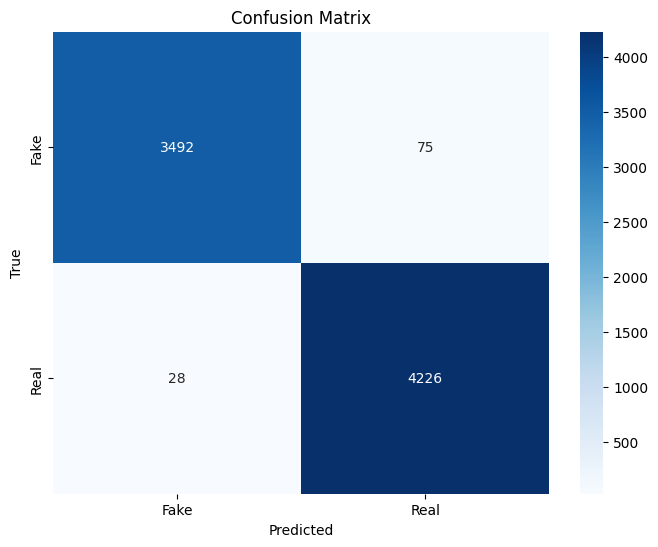

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


y_pred_probs = model.predict(x_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test_one_hot, axis=1)
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [29]:
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

maxlen = 200

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

model = tf.keras.models.load_model("best_model.keras")

with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

In [30]:
def predict_article(text):
    tokens = process_text(text)

    seq = tokenizer.texts_to_sequences([tokens])

    padded = pad_sequences(seq, maxlen=maxlen)

    probs = model.predict(padded)[0]
    pred_idx = np.argmax(probs)
    
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    return pred_label, probs

# Check against CNN article presumed real

In [31]:
new_article = """
After ‘progress’ in talks to end Ukraine war, US diplomacy faces Kremlin test
Inside the Witkoff Group’s exclusive Shell Bay private members club in South Florida, the delegations from Washington and Kyiv faced each other for “tough but very constructive” negotiations over lashings of Ukrainian Borsch, a beetroot and cabbage soup which one attendee told me was “very rich with meat.”

But its serving, along with Holubtsi, traditional meat and cabbage rolls, was seen as a welcome nod to Ukrainian culture – a deft diplomatic gesture as the US tries to coax Ukraine towards compromising on a peace deal with Russia.

A source with direct knowledge of the Florida talks – involving US Secretary of State Marco Rubio, Special Envoy Steve Witkoff and President Donald Trump’s son-in-law Jared Kushner – tells CNN the intensive negotiations were a “step forward” and “built on progress in Geneva,” where a first round of discussions on US proposals to end the Russian war in Ukraine were held last week.

“It would be very premature to say we finalized everything here as a lot of things have still to be done,” the source told CNN.

“But the meeting was very focused and the most problematic aspects of the peace proposals were discussed in detail,” the source added, hinting that tentative progress in some areas could be made.

One of the most “problematic aspects” of the original 28-point US peace proposal was the stipulation for Ukraine to formally renounce its aspiration, enshrined in its constitution, to join NATO – a key Russian demand to end the war and something Ukrainian officials continue to reject.
However, the CNN source now says negotiators have discussed a possible scenario in which Ukraine would effectively be barred from joining the US-led Western military alliance via arrangements that would have to be negotiated directly between NATO member states and Moscow.

“Ukraine will not be pushed to officially, in the legal sense, reject this aspiration,” the source told CNN.

“But if the United States has something to agree upon with Russia bilaterally, or if Russia wants to receive some assurances from NATO multilaterally, then this is not engaging Ukraine in the decision-making process,” the source added.

A final decision on what would be a highly sensitive compromise – likely to be unpopular among NATO states – has not yet been taken and would ultimately be made by the Ukrainian president, the source stressed to CNN.

But it suggests that, as US-Ukraine negotiations proceed, and as Witkoff travels to Moscow for talks at the Kremlin, creative solutions to tiptoe around Kyiv’s red lines are being explored.

Another one of those problematic﻿ areas is the Kremlin demand, which also found its way into the 28-point US peace proposal, for Ukraine to surrender territory in the Donbas region of Eastern Ukraine that has been annexed, but not yet conquered, by Russia.
The US plan suggested the region, which includes a “fortress belt” of heavily defended towns and cities seen as crucial to Ukrainian security, become a Russian demilitarized zone, which Moscow would administer but not deploy military forces into.

The source, who has direct knowledge of the negotiations, tells CNN that discussions are also progressing on this issue – one of the most controversial in the negotiations.

“The idea to give up the control to Russians, where it would significantly weaken Ukraine’s defense and make further potential aggression more likely to happen and significantly decrease Ukraine’s capability, this is out of the scope,” the source told CNN.

“But that doesn’t mean that there are no potential ways of preserving the constitutional provisions and keeping Ukraine’s security,” the source added.

However, the source refused to discuss what specific options are under discussion, saying the issue is “too sensitive.”

“I really believe that if it becomes public, we may ruin the potential solution,” the source told CNN.

There may be another spoiler unmasked in the days ahead too: a Kremlin that has so far refused to curb any of its maximalist demands to subjugate Ukraine before ending the war.

Amid hints of Ukrainian compromises being forged by US negotiators, the next and bigger challenge in America’s shuttle diplomacy may be getting Russia to accept them.
Data as of November 23, 2025.

Notes: “Assessed” means the Institute for the Study of War has received reliable and independently verifiable information to demonstrate Russian control or advances in those areas.

Source: The Institute for the Study of War with AEI’s Critical Threats Project

Graphic: Rachel Wilson and Soph Warnes, CNN
"""

label, probabilities = predict_article(new_article)

print("Predicted label:", label)  # e.g. "FAKE" or "REAL"
print("Class probabilities:", probabilities)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Predicted label: 1
Class probabilities: [0.23791239 0.76208764]


# "Half-True" Article from PolitiFact

In [32]:
new_article = """
Reports that a Trump administration change might make it harder for aspiring nurses to pay for their education sparked outrage online. 

Some social media users said President Donald Trump had signed legislation demoting nursing degrees from professional degree status or reclassifying nursing degrees as non-professional degrees. 

"The Dept. of Education just removed nursing from the list of ‘professional degree’ programs under the Administration’s new loan rules — a move nurses say threatens the future of patient care," radio personality Angela Yee wrote Nov. 20 on Facebook. 

Other social media posts passed on lists of degrees no longer considered "professional" under Trump, including nursing and also physical therapy, architecture, accounting, teaching, engineering and social work. 

Graduate nursing students could soon face new federal borrowing limits, but these comments mislead by saying the Trump administration took nurses’ "professional" classification away.

Trump’s sweeping One Big Beautiful Bill Act set federal loan borrowing limits for nonprofessional and professional graduate students. The first step in implementing those new loan limits is defining which degrees are "professional." 

An Education Department committee agreed on 11 professional degrees based on an existing definition in federal code; the decision is not final. 

Nursing was not demoted or removed; it wasn’t on the list of professional degrees to start. 

However, the changes mean students pursuing graduate degrees in nursing would have a lower borrowing cap compared with borrowers enrolled in professional degrees.

The new loan caps don’t affect undergraduate students, and not all nursing jobs require graduate degrees.
A committee rule has not been finalized
One provision in One Big Beautiful Bill Act eliminated a loan program that allows graduate students to borrow enough money to cover their program’s full cost. That program provided for limitless borrowing, said higher education finance expert and University of Tennessee, Knoxville professor Robert Kelchen.

In its place, the Trump-era law implements new federal loan limits beginning July 1, 2026: up to $20,500 every academic year and $100,000 in total for grad students pursuing nonprofessional degrees and up to $50,000 every academic year and $200,000 in total for grad students seeking professional degrees. 

The law defines professional students as those enrolled in degrees listed in federal code. That section lists examples of professional degrees that "include but are not limited to":

Pharmacy (Pharm.D.) 

Dentistry (D.D.S. or D.M.D.) 

Veterinary Medicine (D.V.M.) 

Chiropractic (D.C. or D.C.M.) 

Law (L.L.B. or J.D.) 

Medicine (M.D.)

Optometry (O.D.).

Osteopathic Medicine (D.O.).

Podiatry (D.P.M., D.P., or Pod.D.).

Theology (M.Div., or M.H.L.)

Nursing was never on that list. But graduate nursing students will be affected by the lower cap for nonprofessional graduate students. 

"That distinction did not matter because graduate and professional students largely had the exact same loan limits," Kelchen said. "Now, that distinction matters."

On Nov. 6, a committee charged with implementing the federal student loan changes approved a definition for  "professional students" that included the 10 degrees listed in federal code and clinical psychology. The committee also approved an expanded list of related programs that fall under those fields as "professional," such as forensic psychology and counseling psychology.

The public comment period is expected in early 2026, the department said. 

The Education Department referred PolitiFact to a Nov. 24 "myth vs. fact" press release, which said its data shows 95% of nursing students borrow below the yearly loan limits and "are not affected by the new caps."

Loan limits will affect financing for advanced nursing degrees
Previously, only people seeking advanced nursing degrees would have qualified for the graduate loan program that had no borrowing limits, known as Graduate PLUS. 

About 45% of nurses entered the workforce with bachelor’s degrees, according to a March 2024 National Center for Health Workforce Analysis report. Some nurses have less than a bachelor’s degree; others start their careers after obtaining advanced degrees. 

Some nurses choose to pursue a master’s (17%) or doctorate degree (3%) after they start working. Half of nurses said they used loans, and most nurses used federal student loans to finance their initial nursing degree, the report said.

It typically takes two to three years to earn a nursing master’s degree and roughly five to eight years to earn a doctorate in nursing, Debra Barksdale, president of the American Academy of Nursing, said.

Nurse practitioners, who must complete master’s or doctoral degree programs, fill in some gaps between nurses and doctors. They can perform and interpret diagnostic tests and diagnose and treat some conditions. 

"The current demand for master’s- and doctorally-prepared nurses for advanced practice, clinical specialties, teaching and research roles far outstrips the supply," Barksdale said. 

Capping federal loans for graduate nursing programs could result in fewer nurses, Barksdale said.

Graduate nursing degree program costs vary. Some historic research shows that by the time nursing students complete their advanced degrees, they have borrowed less than $100,000. It’s unclear how that breaks down year-by-year for the annual $20,500 cap. 

Of 140 advanced nursing programs with debt data, 115 programs’ data showed their 2019 and 2020 graduates finished degrees with median student debt below $100,000, wrote Preston Cooper, an American Enterprise Institute higher education finance expert. He said lower-cost schooling options exist. 

"""

label, probabilities = predict_article(new_article)

print("Predicted label:", label)
print("Class probabilities:", probabilities)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted label: 1
Class probabilities: [0.33452246 0.6654776 ]


# Fake Article from PolitiFact

In [33]:
new_article = """
“RFK Jr. flees the scene after Novo Nordisk Executive Gordon Findlay collapsed in the Oval Office.”
Video clips of a man collapsing Nov. 6 at President Donald Trump’s drug pricing announcement quickly spiraled into misleading narratives. 

Dave Ricks, chair and chief executive officer of Eli Lilly and Co., was speaking in the Oval Office when a man standing behind him fainted. Television cameras captured Health and Human Services Secretary Robert F. Kennedy Jr. leaving the room as other people, including federal health official Dr. Mehmet Oz, treated the man who collapsed. 

After White House officials paused the event, social media users misleadingly jumped to conclusions about the man’s identity and Kennedy’s response.

"BREAKING: RFK Jr. flees the scene after Novo Nordisk Executive Gordon Findlay collapsed in the Oval Office," says the caption of a Nov. 6 X post that had more than 3 million views as of Nov. 7.

Other social media posts on TikTok and X shared similar claims, including X’s artificial intelligence-powered chatbot Grok, who responded to users that Gordon Findlay was the person who fainted in the Oval Office.

These posts named the wrong person, and the White House disputes the explanation for Kennedy’s exit.
Here’s what we know about the incident at Trump’s event with Eli Lilly and Novo Nordisk executives to lower prices for popular pharmaceutical drugs such as GLP-1 weight loss medications.
"""

label, probabilities = predict_article(new_article)

print("Predicted label:", label)  # e.g. "FAKE" or "REAL"
print("Class probabilities:", probabilities)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted label: 0
Class probabilities: [0.96684784 0.03315213]


In [34]:
import tensorflow as tf
import numpy as np

embedding_layer = model.layers[1]

emb_dim = embedding_layer.output_dim
emb_input = tf.keras.Input(shape=(maxlen, emb_dim))

x = emb_input
for layer in model.layers[2:]:
    x = layer(x)

rest_model = tf.keras.Model(emb_input, x)

In [35]:
def explain_article(text, top_k=20):

    tokens = process_text(text) 

    
    seq = tokenizer.texts_to_sequences([" ".join(tokens)])
    seq = np.array(seq)

    
    padded = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=maxlen)

    preds = model.predict(padded)
    pred_class = np.argmax(preds[0])

    
    with tf.GradientTape() as tape:
        embeddings = embedding_layer(padded)
        tape.watch(embeddings)

        outputs = rest_model(embeddings)
        target = outputs[:, pred_class]

    grads = tape.gradient(target, embeddings)

    token_importance = tf.norm(grads, axis=-1).numpy()[0]

    seq_ids = padded[0]
    non_pad_mask = seq_ids != 0
    token_ids = seq_ids[non_pad_mask]
    token_scores = token_importance[non_pad_mask]

    id2word = {idx: word for word, idx in tokenizer.word_index.items()}
    words = [id2word.get(int(tid), "[UNK]") for tid in token_ids]

    if len(token_scores) > 0:
        token_scores = token_scores / (token_scores.max() + 1e-8)

    word_importances = list(zip(words, token_scores))

    word_importances_sorted = sorted(
        word_importances, key=lambda x: x[1], reverse=True
    )

    return word_importances_sorted[:top_k], pred_class, preds[0]

In [36]:
article = """
After ‘progress’ in talks to end Ukraine war, US diplomacy faces Kremlin test
Inside the Witkoff Group’s exclusive Shell Bay private members club in South Florida, the delegations from Washington and Kyiv faced each other for “tough but very constructive” negotiations over lashings of Ukrainian Borsch, a beetroot and cabbage soup which one attendee told me was “very rich with meat.”

But its serving, along with Holubtsi, traditional meat and cabbage rolls, was seen as a welcome nod to Ukrainian culture – a deft diplomatic gesture as the US tries to coax Ukraine towards compromising on a peace deal with Russia.

A source with direct knowledge of the Florida talks – involving US Secretary of State Marco Rubio, Special Envoy Steve Witkoff and President Donald Trump’s son-in-law Jared Kushner – tells CNN the intensive negotiations were a “step forward” and “built on progress in Geneva,” where a first round of discussions on US proposals to end the Russian war in Ukraine were held last week.

“It would be very premature to say we finalized everything here as a lot of things have still to be done,” the source told CNN.

“But the meeting was very focused and the most problematic aspects of the peace proposals were discussed in detail,” the source added, hinting that tentative progress in some areas could be made.

One of the most “problematic aspects” of the original 28-point US peace proposal was the stipulation for Ukraine to formally renounce its aspiration, enshrined in its constitution, to join NATO – a key Russian demand to end the war and something Ukrainian officials continue to reject.
However, the CNN source now says negotiators have discussed a possible scenario in which Ukraine would effectively be barred from joining the US-led Western military alliance via arrangements that would have to be negotiated directly between NATO member states and Moscow.

“Ukraine will not be pushed to officially, in the legal sense, reject this aspiration,” the source told CNN.

“But if the United States has something to agree upon with Russia bilaterally, or if Russia wants to receive some assurances from NATO multilaterally, then this is not engaging Ukraine in the decision-making process,” the source added.

A final decision on what would be a highly sensitive compromise – likely to be unpopular among NATO states – has not yet been taken and would ultimately be made by the Ukrainian president, the source stressed to CNN.

But it suggests that, as US-Ukraine negotiations proceed, and as Witkoff travels to Moscow for talks at the Kremlin, creative solutions to tiptoe around Kyiv’s red lines are being explored.

Another one of those problematic﻿ areas is the Kremlin demand, which also found its way into the 28-point US peace proposal, for Ukraine to surrender territory in the Donbas region of Eastern Ukraine that has been annexed, but not yet conquered, by Russia.
The US plan suggested the region, which includes a “fortress belt” of heavily defended towns and cities seen as crucial to Ukrainian security, become a Russian demilitarized zone, which Moscow would administer but not deploy military forces into.

The source, who has direct knowledge of the negotiations, tells CNN that discussions are also progressing on this issue – one of the most controversial in the negotiations.

“The idea to give up the control to Russians, where it would significantly weaken Ukraine’s defense and make further potential aggression more likely to happen and significantly decrease Ukraine’s capability, this is out of the scope,” the source told CNN.

“But that doesn’t mean that there are no potential ways of preserving the constitutional provisions and keeping Ukraine’s security,” the source added.

However, the source refused to discuss what specific options are under discussion, saying the issue is “too sensitive.”

“I really believe that if it becomes public, we may ruin the potential solution,” the source told CNN.

There may be another spoiler unmasked in the days ahead too: a Kremlin that has so far refused to curb any of its maximalist demands to subjugate Ukraine before ending the war.

Amid hints of Ukrainian compromises being forged by US negotiators, the next and bigger challenge in America’s shuttle diplomacy may be getting Russia to accept them.
Data as of November 23, 2025.

Notes: “Assessed” means the Institute for the Study of War has received reliable and independently verifiable information to demonstrate Russian control or advances in those areas.

Source: The Institute for the Study of War with AEI’s Critical Threats Project

Graphic: Rachel Wilson and Soph Warnes, CNN
"""

important_words, pred_class_idx, class_probs = explain_article(
    article, top_k=15
)

print("Predicted class index:", pred_class_idx)
print("Class probabilities:", class_probs)
pred_label = label_encoder.inverse_transform([pred_class_idx])[0]
print("Predicted label:", pred_label)
print("\nMost influential tokens (word, normalized_importance):")
for w, s in important_words:
    print(f"{w:15s}  {s:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted class index: 1
Class probabilities: [0.23791239 0.76208764]
Predicted label: 1

Most influential tokens (word, normalized_importance):
rubio            1.000
marco            0.990
special          0.962
envoy            0.934
steve            0.920
president        0.906
donald           0.895
trump            0.874
jared            0.860
kushner          0.859
tell             0.840
intensive        0.819
geneva           0.810
built            0.809
first            0.807


In [37]:
import requests
from bs4 import BeautifulSoup
import numpy as np


def fetch_article_text(url, timeout=10):
    resp = requests.get(url, timeout=timeout)
    soup = BeautifulSoup(resp.text, "html.parser")
    for tag in soup(
        [
            "script",
            "style",
            "noscript",
            "header",
            "footer",
            "form",
            "nav",
            "aside",
        ]
    ):
        tag.decompose()
    article = soup.find("article")
    if article:
        paragraphs = article.find_all("p")
    else:
        paragraphs = soup.find_all("p")
    texts = [
        p.get_text(" ", strip=True)
        for p in paragraphs
        if p.get_text(strip=True)
    ]
    return "\n".join(texts).strip()


def explain_from_url(url, top_k=20):
    text = fetch_article_text(url)
    tokens = process_text(text)
    seq = tokenizer.texts_to_sequences([" ".join(tokens)])
    seq = np.array(seq)
    padded = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=maxlen)
    preds = model.predict(padded)
    pred_class = np.argmax(preds[0])
    with tf.GradientTape() as tape:
        embeddings = embedding_layer(padded)
        tape.watch(embeddings)
        outputs = rest_model(embeddings)
        target = outputs[:, pred_class]
    grads = tape.gradient(target, embeddings)
    token_importance = tf.norm(grads, axis=-1).numpy()[0]
    seq_ids = padded[0]
    non_pad_mask = seq_ids != 0
    token_ids = seq_ids[non_pad_mask]
    token_scores = token_importance[non_pad_mask]
    id2word = {idx: word for word, idx in tokenizer.word_index.items()}
    words = [id2word.get(int(tid), "[UNK]") for tid in token_ids]
    if len(token_scores) > 0:
        token_scores = token_scores / (token_scores.max() + 1e-8)
    word_importances = list(zip(words, token_scores))
    word_importances_sorted = sorted(
        word_importances, key=lambda x: x[1], reverse=True
    )
    return word_importances_sorted[:top_k], pred_class, preds[0]


def sanitize_importances(word_importances, decimals=3):
    return [(w, round(float(s), decimals)) for w, s in word_importances]


def explain_from_url_readable(url, top_k=20):
    wi, pred_class, probs = explain_from_url(url, top_k=top_k)
    wi_clean = [(w, round(float(s), 3)) for w, s in wi]
    pred_label = "real" if pred_class == 1 else "fake"
    return {
        "prediction": pred_label,
        "probabilities": probs.tolist(),
        "important_tokens": wi_clean,
    }

In [38]:
url = "https://edition.cnn.com/2025/12/01/europe/us-ukraine-talks-russia-war-analysis-intl-hnk"
explain_from_url_readable(url)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


{'prediction': 'real',
 'probabilities': [0.22747865319252014, 0.7725213170051575],
 'important_tokens': [('gesture', 1.0),
  ('coax', 0.994),
  ('ukraine', 0.991),
  ('towards', 0.986),
  ('direct', 0.98),
  ('peace', 0.98),
  ('deal', 0.979),
  ('compromising', 0.978),
  ('russia', 0.972),
  ('source', 0.972),
  ('talk', 0.969),
  ('involving', 0.966),
  ('knowledge', 0.966),
  ('secretary', 0.964),
  ('marco', 0.948),
  ('rubio', 0.942),
  ('state', 0.94),
  ('special', 0.917),
  ('steve', 0.888),
  ('envoy', 0.885)]}